In [49]:
# https://github.com/quamrl-hoda/swiggy-delivery-time-prediction-system/blob/main/notebooks/EDA.ipynb

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency,f_oneway,jarque_bera,probplot
import plotly.express as px

In [51]:
df=pd.read_csv("../data/raw/cleaned_data.csv")

In [52]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,Morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,Evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,Morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,Evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,Afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,Windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,Morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,Windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,Evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,Cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,Night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,Cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,Afternoon,6.232393


In [53]:
df.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [54]:
#number of rows having missing values
missing_rows=df.isnull().any(axis=1).sum()
print(f"there are {missing_rows} in the data")
print(f"and it accounts for {(missing_rows/df.shape[0])*100:.2f}% of tota data")

there are 7438 in the data
and it accounts for 16.35% of tota data


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries     float64
festival                 object
city_type                object
time_taken                int64
city_name                object
order_day                 int64
order_month               int64
order_day_of_week        object
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day        object
distance                float64
dtype: object

In [57]:
#Numerical and categorical columns
cat_cols=[col for col in df.columns.tolist() if df[col].dtype=='object']
num_cols=[col for col in df.columns.tolist() if col not in cat_cols]

In [58]:
print(cat_cols,len(cat_cols))
print(num_cols,len(num_cols))

['rider_id', 'order_date', 'weather', 'traffic', 'type_of_order', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day'] 11
['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'vehicle_condition', 'multiple_deliveries', 'time_taken', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance'] 15


In [59]:
df[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [60]:
#statistical summary of categorical columns
df.assign(**{col:df[col].astype("object") for col in cat_cols}).describe(include="object").T

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,Fog,7654
traffic,44992,4,low,15477
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029
city_name,45502,22,JAP,3439
order_day_of_week,45502,7,wednesday,7077


<Axes: >

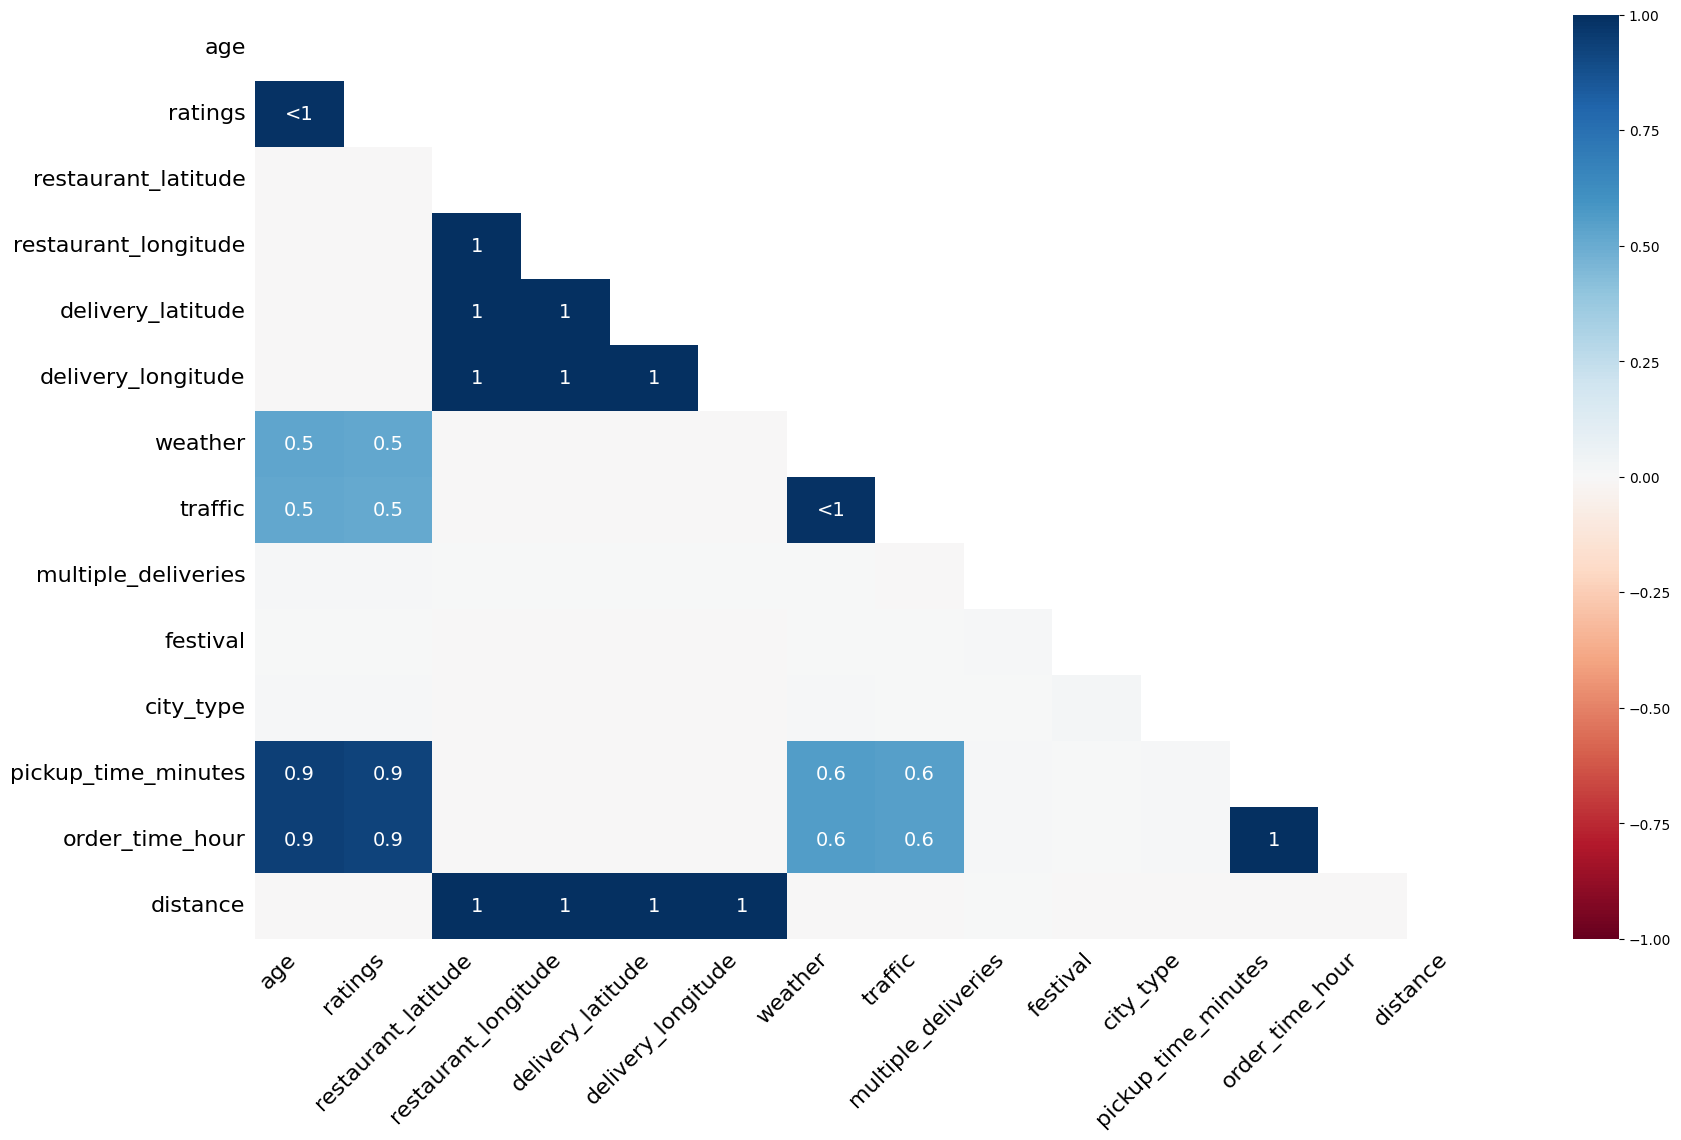

In [61]:
import missingno as msno 
msno.heatmap(df)


In [62]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [63]:
df.drop(columns=['restaurant_latitude','restaurant_longitude', 'delivery_latitude', 'delivery_longitude'])

,rider_id,age,ratings,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,2022-03-19,Sunny,high,2,snack,motorcycle,0.0,...,24,INDO,19,3,saturday,1,15.0,11.0,Morning,3.025149
1,BANGRES18DEL02,34.0,4.5,2022-03-25,Stormy,jam,2,snack,scooter,1.0,...,33,BANG,25,3,friday,0,5.0,19.0,Evening,20.183530
2,BANGRES19DEL01,23.0,4.4,2022-03-19,Sandstorms,low,0,drinks,motorcycle,1.0,...,26,BANG,19,3,saturday,1,15.0,8.0,Morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,2022-04-05,Sunny,medium,0,buffet,motorcycle,1.0,...,21,COIMB,5,4,tuesday,0,10.0,18.0,Evening,7.790401
4,CHENRES12DEL01,32.0,4.6,2022-03-26,Cloudy,high,1,snack,scooter,1.0,...,30,CHEN,26,3,saturday,1,15.0,13.0,Afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,2022-03-24,Windy,high,1,meal,motorcycle,0.0,...,32,JAP,24,3,thursday,0,10.0,11.0,Morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,2022-02-16,Windy,jam,0,buffet,motorcycle,1.0,...,36,AGR,16,2,wednesday,0,15.0,19.0,Evening,NaN
45499,CHENRES08DEL03,30.0,4.9,2022-03-11,Cloudy,low,1,drinks,scooter,0.0,...,16,CHEN,11,3,friday,0,15.0,23.0,Night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,2022-03-07,Cloudy,high,0,snack,motorcycle,1.0,...,26,COIMB,7,3,monday,0,5.0,13.0,Afternoon,6.232393


### Functions to perform analysis

##### -Univariate Analysis, Bivariate analysis , Multivariate analysis

In [64]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15,10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name,hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name,hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name,bins=bins,hue=cat_col,kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()

def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")

def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")

def test_for_normality(dataframe, column_name, alpha=0.05):
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")